# FIFA World Cup 2026 — Goalkeeper Workload vs. Save Efficiency

**Analytic question:** Do goalkeepers who face more shots on target (SoTA) end up with a higher save percentage than those who face fewer shots on target?

**Data source:** FBref — 2026 World Cup Player Goalkeeping Stats
(https://fbref.com/en/comps/1/keepers/World-Cup-Stats)

**Before running:** upload `sportsref_download__1_.xls` to this Colab session (folder icon on the left sidebar → upload).

## Step 0: Setup — imports and configuration

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
from io import StringIO
import matplotlib.pyplot as plt

RANDOM_SEED = 42
RAW_FILE = "sportsref_download_goalkeeping.xls"
ALPHA = 0.05

## Step 1: Data Wrangling

Load the raw FBref HTML export, flatten its multi-level column headers, and clean it into a tidy dataframe.

In [ ]:
with open(RAW_FILE, encoding="utf-8") as f:
    html_content = f.read()

tables = pd.read_html(StringIO(html_content))
df = tables[0]

df.head()

Unnamed: 0_level_0 Unnamed: 1_level_0 Unnamed: 2_level_0 Unnamed: 3_level_0  \
                  Rk             Player                Pos              Squad   
0                  1    Yazeed Abulaila                 GK          jo Jordan   
1                  2    Mahmoud Abunada                 GK           qa Qatar   
2                  3            Alisson                 GK          br Brazil   
3                  4     Benjamin Asare                 GK           gh Ghana   
4                  5  Lawrence Ati-Zigi                 GK           gh Ghana   

  Unnamed: 4_level_0        Unnamed: 5_level_0 Unnamed: 6_level_0  \
                 Age                      Club               Born   
0                 33        1.jo Al-Hussein SC               1993   
1                 26         1.qa Al Rayyan SC               2000   
2                 33           1.eng Liverpool               1992   
3                 33  1.gh Accra Hearts of Oak               1992   
4                 29           1.ch St. Gallen               1996   

  Playing Time              ... Performance              Penalty Kicks      \
            MP Starts  Min  ...           D  L CS    CS%         PKatt PKA   
0            3      3  270  ...           0  3  0    0.0             2   2   
1            3      3  270  ...           1  2  0    0.0             1   1   
2            5      5  450  ...           1  1  2   40.0             0   0   
3            3      2  225  ...           1  1  2  100.0             0   0   
4            2      2  135  ...           0  1  1   50.0             0   0   

                 Unnamed: 26_level_0  
  PKsv PKm Save%             Matches  
0    0   0   0.0             Matches  
1    0   0   0.0             Matches  
2    0   0   NaN             Matches  
3    0   0   NaN             Matches  
4    0   0   NaN             Matches  

[5 rows x 27 columns]

Flatten the two-level column headers (e.g. `('Performance', 'Save%')` becomes `Performance_Save%`):

In [ ]:
df.columns = [
    c[1] if "Unnamed" in c[0] else f"{c[0]}_{c[1]}" for c in df.columns
]

df.columns.tolist()

['Rk',
 'Player',
 'Pos',
 'Squad',
 'Age',
 'Club',
 'Born',
 'Playing Time_MP',
 'Playing Time_Starts',
 'Playing Time_Min',
 'Playing Time_90s',
 'Performance_GA',
 'Performance_GA90',
 'Performance_SoTA',
 'Performance_Saves',
 'Performance_Save%',
 'Performance_W',
 'Performance_D',
 'Performance_L',
 'Performance_CS',
 'Performance_CS%',
 'Penalty Kicks_PKatt',
 'Penalty Kicks_PKA',
 'Penalty Kicks_PKsv',
 'Penalty Kicks_PKm',
 'Penalty Kicks_Save%',
 'Matches']

Drop non-analytical columns and check for duplicates/missing values:

In [ ]:
df = df.drop(columns=["Rk", "Matches"])

print("Duplicate players:", df["Player"].duplicated().sum())
print("Missing Save%:", df["Performance_Save%"].isnull().sum())
print("Missing SoTA:", df["Performance_SoTA"].isnull().sum())

df.head()

Duplicate players: 0
Missing Save%: 3
Missing SoTA: 0


,Player,Pos,Squad,Age,Club,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Playing Time_90s,...,Performance_W,Performance_D,Performance_L,Performance_CS,Performance_CS%,Penalty Kicks_PKatt,Penalty Kicks_PKA,Penalty Kicks_PKsv,Penalty Kicks_PKm,Penalty Kicks_Save%
0,Yazeed Abulaila,GK,jo Jordan,33,1.jo Al-Hussein SC,1993,3,3,270,3.0,...,0,0,3,0,0.0,2,2,0,0,0.0
1,Mahmoud Abunada,GK,qa Qatar,26,1.qa Al Rayyan SC,2000,3,3,270,3.0,...,0,1,2,0,0.0,1,1,0,0,0.0
2,Alisson,GK,br Brazil,33,1.eng Liverpool,1992,5,5,450,5.0,...,3,1,1,2,40.0,0,0,0,0,NaN
3,Benjamin Asare,GK,gh Ghana,33,1.gh Accra Hearts of Oak,1992,3,2,225,2.5,...,0,1,1,2,100.0,0,0,0,0,NaN
4,Lawrence Ati-Zigi,GK,gh Ghana,29,1.ch St. Gallen,1996,2,2,135,1.5,...,1,0,1,1,50.0,0,0,0,0,NaN


## Step 2: Data Preparation & Sampling

**Population:** goalkeepers who played at least 1 match, with a defined Save% and SoTA.
**Sampling:** simple random sample without replacement, 70% of the population, fixed seed for reproducibility.
**Grouping variable:** split into High/Low Workload based on the sample median of SoTA.

In [ ]:
population = df[df["Playing Time_MP"] > 0].copy()
population_valid = population.dropna(subset=["Performance_Save%", "Performance_SoTA"]).copy()

print(f"Population size: {len(population_valid)}")
population_valid.head()

Population size: 59


,Player,Pos,Squad,Age,Club,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Playing Time_90s,...,Performance_W,Performance_D,Performance_L,Performance_CS,Performance_CS%,Penalty Kicks_PKatt,Penalty Kicks_PKA,Penalty Kicks_PKsv,Penalty Kicks_PKm,Penalty Kicks_Save%
0,Yazeed Abulaila,GK,jo Jordan,33,1.jo Al-Hussein SC,1993,3,3,270,3.0,...,0,0,3,0,0.0,2,2,0,0,0.0
1,Mahmoud Abunada,GK,qa Qatar,26,1.qa Al Rayyan SC,2000,3,3,270,3.0,...,0,1,2,0,0.0,1,1,0,0,0.0
2,Alisson,GK,br Brazil,33,1.eng Liverpool,1992,5,5,450,5.0,...,3,1,1,2,40.0,0,0,0,0,NaN
3,Benjamin Asare,GK,gh Ghana,33,1.gh Accra Hearts of Oak,1992,3,2,225,2.5,...,0,1,1,2,100.0,0,0,0,0,NaN
4,Lawrence Ati-Zigi,GK,gh Ghana,29,1.ch St. Gallen,1996,2,2,135,1.5,...,1,0,1,1,50.0,0,0,0,0,NaN


In [ ]:
sample = population_valid.sample(frac=0.70, random_state=RANDOM_SEED)

print(f"Sample size: {len(sample)}")
sample.head()

Sample size: 41


,Player,Pos,Squad,Age,Club,Born,Playing Time_MP,Playing Time_Starts,Playing Time_Min,Playing Time_90s,...,Performance_W,Performance_D,Performance_L,Performance_CS,Performance_CS%,Penalty Kicks_PKatt,Penalty Kicks_PKA,Penalty Kicks_PKsv,Penalty Kicks_PKm,Penalty Kicks_Save%
0,Yazeed Abulaila,GK,jo Jordan,33,1.jo Al-Hussein SC,1993,3,3,270,3.0,...,0,0,3,0,0.0,2,2,0,0,0.0
5,Ahmed Basil,GK,iq Iraq,29,1.iq Al-Shorta,1996,2,2,135,1.5,...,0,0,2,0,0.0,0,0,0,0,NaN
34,Fernando Muslera,GK,uy Uruguay,39,1.tr Galatasaray,1986,3,3,225,2.5,...,0,2,1,0,0.0,0,0,0,0,NaN
13,Thibaut Courtois,GK,be Belgium,34,1.es Real Madrid,1992,6,6,550,6.1,...,3,2,1,1,16.7,0,0,0,0,NaN
48,Egil Selvik,GK,no Norway,28,2.eng Watford,1997,1,1,90,1.0,...,0,0,1,0,0.0,0,0,0,0,NaN


In [ ]:
median_sota = sample["Performance_SoTA"].median()
sample["workload_group"] = np.where(
    sample["Performance_SoTA"] > median_sota, "High Workload", "Low Workload"
)

print(f"Median SoTA (sample): {median_sota}")
sample["workload_group"].value_counts()

Median SoTA (sample): 15.0


,count
workload_group,
Low Workload,22
High Workload,19


## Step 3: Descriptive Statistics

Summarise the sample overall and by workload group.

In [ ]:
overall = sample["Performance_Save%"]

print("Overall sample:")
print(f"  n      = {len(overall)}")
print(f"  Mean   = {overall.mean():.2f}%")
print(f"  Median = {overall.median():.2f}%")
print(f"  SD     = {overall.std(ddof=1):.2f}")
print(f"  Min/Max= {overall.min():.1f}% / {overall.max():.1f}%")

Overall sample:
  n      = 41
  Mean   = 57.97%
  Median = 60.00%
  SD     = 20.45
  Min/Max= 0.0% / 88.9%


In [ ]:
for grp, sub in sample.groupby("workload_group"):
    s = sub["Performance_Save%"]
    print(f"\n{grp} (n={len(s)}):")
    print(f"  Mean   = {s.mean():.2f}%")
    print(f"  Median = {s.median():.2f}%")
    print(f"  SD     = {s.std(ddof=1):.2f}")
    print(f"  Min/Max= {s.min():.1f}% / {s.max():.1f}%")


High Workload (n=19):
  Mean   = 67.46%
  Median = 70.00%
  SD     = 10.53
  Min/Max= 50.0% / 86.4%

Low Workload (n=22):
  Mean   = 49.78%
  Median = 55.60%
  SD     = 23.44
  Min/Max= 0.0% / 88.9%


## Step 4: 95% Confidence Interval

Estimate a confidence interval for the population mean save percentage.

In [ ]:
n = len(overall)
mean = overall.mean()
sem = stats.sem(overall)
ci_low, ci_high = stats.t.interval(0.95, df=n - 1, loc=mean, scale=sem)

print(f"Sample mean save% = {mean:.2f}%")
print(f"Standard error     = {sem:.3f}")
print(f"95% CI for population mean save% = ({ci_low:.2f}%, {ci_high:.2f}%)")

Sample mean save% = 57.97%
Standard error     = 3.193
95% CI for population mean save% = (51.52%, 64.43%)


## Step 5: Two-Sample t-Test

**H0:** mean save% (High Workload) = mean save% (Low Workload)
**H1:** mean save% (High Workload) ≠ mean save% (Low Workload)
**α = 0.05**

Welch's t-test is used (not assuming equal variances), since the two groups' standard deviations differ noticeably.

In [ ]:
grp_high = sample[sample["workload_group"] == "High Workload"]["Performance_Save%"]
grp_low = sample[sample["workload_group"] == "Low Workload"]["Performance_Save%"]

t_stat, p_val = stats.ttest_ind(grp_high, grp_low, equal_var=False)

print(f"High Workload: n={len(grp_high)}, mean={grp_high.mean():.2f}%, sd={grp_high.std(ddof=1):.2f}")
print(f"Low Workload:  n={len(grp_low)}, mean={grp_low.mean():.2f}%, sd={grp_low.std(ddof=1):.2f}")
print(f"\nWelch's t-statistic = {t_stat:.4f}")
print(f"p-value (two-tailed) = {p_val:.4f}")

if p_val < ALPHA:
    print("\nDecision: Reject H0 — significant difference in save% between High and Low workload keepers.")
else:
    print("\nDecision: Fail to reject H0 — no significant difference at alpha=0.05.")

High Workload: n=19, mean=67.46%, sd=10.53
Low Workload:  n=22, mean=49.78%, sd=23.44

Welch's t-statistic = 3.1841
p-value (two-tailed) = 0.0034

Decision: Reject H0 — significant difference in save% between High and Low workload keepers.


Bonus: Pearson correlation between SoTA and Save% as a supporting statistic.

In [ ]:
corr = sample["Performance_SoTA"].corr(sample["Performance_Save%"])
print(f"Pearson correlation (SoTA vs Save%): {corr:.3f}")

Pearson correlation (SoTA vs Save%): 0.588


## Visualisation: Boxplot of Save% by Workload Group

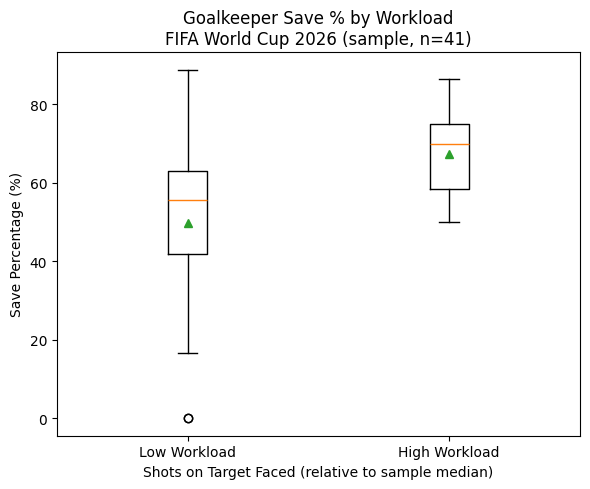

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
groups = ["Low Workload", "High Workload"]
data = [sample[sample["workload_group"] == g]["Performance_Save%"] for g in groups]
ax.boxplot(data, tick_labels=groups, showmeans=True)
ax.set_ylabel("Save Percentage (%)")
ax.set_xlabel("Shots on Target Faced (relative to sample median)")
ax.set_title("Goalkeeper Save % by Workload\nFIFA World Cup 2026 (sample, n=41)")
plt.tight_layout()
plt.show()

## Visualisation: Scatter Plot of SoTA vs Save%

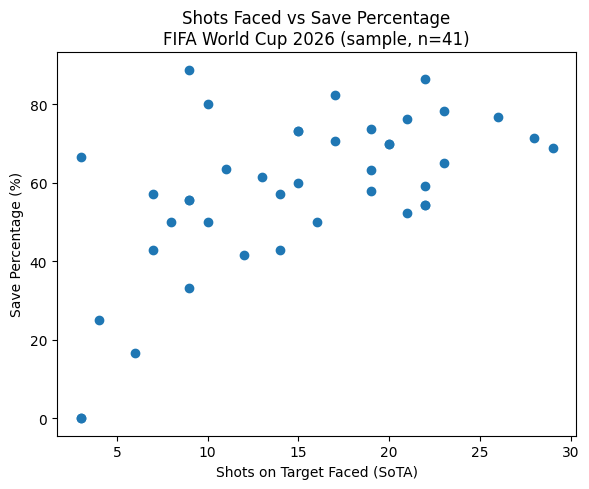

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(sample["Performance_SoTA"], sample["Performance_Save%"])
ax.set_xlabel("Shots on Target Faced (SoTA)")
ax.set_ylabel("Save Percentage (%)")
ax.set_title("Shots Faced vs Save Percentage\nFIFA World Cup 2026 (sample, n=41)")
plt.tight_layout()
plt.show()

## Summary

- Goalkeepers facing more shots on target (High Workload) had a significantly higher average save percentage (67.5%) than those facing fewer (Low Workload, 49.8%).
- Welch's two-sample t-test: t = 3.18, p = 0.0034 → statistically significant at α = 0.05.
- Pearson correlation (SoTA vs Save%) = 0.588, a moderate positive relationship.
- 95% CI for the population mean save% (all WC2026 goalkeepers with ≥1 match): (51.52%, 64.43%).
- **Caveat:** correlation does not imply causation — this does not establish whether facing more shots *causes* better saving, or whether more experienced/better goalkeepers simply tend to face more shots.